In [1]:
import sys
sys.path.append('../src')
from data_loader import update_db, load_from_db, get_db_summary
get_db_summary()

---------------------------------------------
No. Tickers : 40
No. Rows    : 51,605
---------------------------------------------


,Ticker,rows,start_date,end_date
0,ACB,1319,2021-01-04,2026-04-21
1,BCM,1319,2021-01-04,2026-04-21
2,BID,1319,2021-01-04,2026-04-21
3,BVH,1319,2021-01-04,2026-04-21
4,CTG,1319,2021-01-04,2026-04-21
5,DGC,1319,2021-01-04,2026-04-21
6,EIB,1319,2021-01-04,2026-04-21
7,FPT,1319,2021-01-04,2026-04-21
8,GAS,1319,2021-01-04,2026-04-21
9,GMD,1319,2021-01-04,2026-04-21


In [2]:
import sys
sys.path.append('../src')
from data_loader import update_db, load_from_db, get_db_summary
update_db()

✅ Table Stock_Prices ready
📥 Fetching 30 tickers | 2021-01-01 → 2026-04-22
   Source: vnstock3 VCI (fallback: yfinance)



📦 **Vnstock 3.5.1 is available**
Current: 3.5.0 (Python 3.13 (venv))
Update: `D:\Projects\vn-portfolio-optimizer\venv\Scripts\python.exe -m pip install vnstock --upgrade`
Release: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban

📦 **Vnai 2.4.6 is available**
Current: 2.4.0 (Python 3.13 (venv))
Update: `D:\Projects\vn-portfolio-optimizer\venv\Scripts\python.exe -m pip install vnai --upgrade`
Release: https://pypi.org/project/vnai/#history

Thư viện `vnstock3` đã được hợp nhất với tên gọi `vnstock`. Phiên bản mới nhất 3.5.1 đã có mặt.Vui lòng chuyển đổi gói thư viện thành `vnstock` để luôn nhận bản cập nhật với câu lệnh : `pip install vnstock --upgrade`.
Lịch sử phiên bản: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban
Phiên bản hiện tại 3.2.1

  ⚠️  ACB   →     0 rows
  ⚠️  BID   →     0 rows
  ⚠️  CTG   →     0 rows
  ⚠️  DGC   →     0 rows
  ⚠️  FPT   →     0 rows
  ⚠️  GAS   →     0 rows
  ⚠️  GVR   →     0 rows
  ⚠️  HDB   →     0 rows
  ⚠️  HPG   →     0 rows
  ⚠️  LPB   →     0 rows
  ⚠️  MBB   →     0 rows
  ⚠️  MSN   →     0 rows
  ⚠️  MWG   →     0 rows
  ⚠️  PLX   →     0 rows
  ⚠️  SAB   →     0 rows
  ⚠️  SHB   →     0 rows
  ⚠️  SSB   →     0 rows
  ⚠️  SSI   →     0 rows
  ⚠️  STB   →     0 rows
  ⚠️  TCB   →     0 rows
  ⚠️  TPB   →     0 rows
  ⚠️  VCB   →     0 rows
  ⚠️  VHM   →     0 rows
  ⚠️  VIB   →     0 rows
  ⚠️  VIC   →     0 rows
  ⚠️  VJC   →     0 rows
  ⚠️  VNM   →     0 rows
  ⚠️  VPB   →     0 rows
  ⚠️  VPL   →     0 rows
  ⚠️  VRE   →     0 rows

✅ Done. Total new rows: 0

📊 DB Summary:
---------------------------------------------
No. Tickers : 40
No. Rows    : 51,605
---------------------------------------------
Ticker  rows start_date   end_date
   ACB  1319 2021-01-04 2026-04-21
   BCM  

In [3]:
import sys
sys.path.append('../src')
from data_loader import load_from_db
import numpy as np

df = load_from_db('VCB', '2021-01-01', '2026-04-22')

# Tính return rồi export
df['Simple_Return'] = df['Close'].pct_change()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Export ra Excel
df.to_excel('../reports/vcb_returns_verify.xlsx')
print(f"✅ Exported {len(df)} rows")
print(f"File: reports/vcb_returns_verify.xlsx")

✅ Exported 1319 rows
File: reports/vcb_returns_verify.xlsx


In [4]:
from vnstock import Vnstock
import pandas as pd

# Test đủ 10 mã
tickers = ['VCB', 'VNM', 'HPG', 'FPT', 'MWG', 'VIC', 'GAS', 'BID', 'CTG', 'TCB']

results = []
for t in tickers:
    try:
        stock = Vnstock().stock(symbol=t, source='VCI')
        df = stock.quote.history(start='2024-01-01', end='2024-01-31', interval='1D')
        results.append({
            'Ticker': t,
            'Rows': len(df),
            'Close_min': df['close'].min(),
            'Close_max': df['close'].max(),
            'Status': '✅'
        })
    except Exception as e:
        results.append({
            'Ticker': t,
            'Rows': 0,
            'Close_min': None,
            'Close_max': None,
            'Status': f'❌ {type(e).__name__}'
        })

summary = pd.DataFrame(results)
print(summary.to_string(index=False))

Ticker  Rows Close_min Close_max     Status
   VCB     0      None      None ❌ KeyError
   VNM     0      None      None ❌ KeyError
   HPG     0      None      None ❌ KeyError
   FPT     0      None      None ❌ KeyError
   MWG     0      None      None ❌ KeyError
   VIC     0      None      None ❌ KeyError
   GAS     0      None      None ❌ KeyError
   BID     0      None      None ❌ KeyError
   CTG     0      None      None ❌ KeyError
   TCB     0      None      None ❌ KeyError


In [5]:
import sys
sys.path.append('../src')
from data_loader import update_db, load_from_db, get_db_summary
update_db()

✅ Table Stock_Prices ready
📥 Fetching 30 tickers | 2021-01-01 → 2026-04-22
   Source: vnstock3 VCI (fallback: yfinance)

  ✅ ACB   →     1 rows
  ✅ BID   →     1 rows
  ✅ CTG   →     1 rows
  ✅ DGC   →     1 rows
  ✅ FPT   →     1 rows
  ✅ GAS   →     1 rows
  ✅ GVR   →     1 rows
  ✅ HDB   →     1 rows
  ✅ HPG   →     1 rows
  ✅ LPB   →     1 rows
  ✅ MBB   →     1 rows
  ✅ MSN   →     1 rows
  ✅ MWG   →     1 rows
  ✅ PLX   →     1 rows
  ✅ SAB   →     1 rows
  ✅ SHB   →     1 rows
  ✅ SSB   →     1 rows
  ✅ SSI   →     1 rows
  ✅ STB   →     1 rows
  ✅ TCB   →     1 rows
  ✅ TPB   →     1 rows
  ✅ VCB   →     1 rows
  ✅ VHM   →     1 rows
  ✅ VIB   →     1 rows
  ✅ VIC   →     1 rows
  ✅ VJC   →     1 rows
  ✅ VNM   →     1 rows
  ✅ VPB   →     1 rows
  ✅ VPL   →     1 rows
  ✅ VRE   →     1 rows

✅ Done. Total new rows: 30

📊 DB Summary:
---------------------------------------------
No. Tickers : 40
No. Rows    : 51,635
---------------------------------------------
Ticker  rows sta

In [6]:
import sys
import os
import sqlite3
import pandas as pd

# Trỏ đường dẫn vào thư mục src
sys.path.append(os.path.abspath('./src'))
from data_loader import update_db, get_db_summary, VN30_TICKERS, DB_PATH, get_connection

# ---------------------------------------------------------
# BƯỚC 1: XÓA SẠCH HOÀN TOÀN BẢNG DỮ LIỆU (Bao gồm cả mã thừa)
# ---------------------------------------------------------
if os.path.exists(DB_PATH):
    conn = get_connection()
    conn.execute("DROP TABLE IF EXISTS Stock_Prices")
    conn.commit()
    conn.close()
    print("✅ Đã DROP bảng Stock_Prices thành công. Dữ liệu cũ đã bị xóa sạch hoàn toàn.")

# ---------------------------------------------------------
# BƯỚC 2: KÉO LẠI CHUẨN 30 MÃ VN30 (Nguồn KBS)
# ---------------------------------------------------------
print("📥 Bắt đầu kéo lại chuẩn 30 mã VN30...")
update_db(
    tickers=VN30_TICKERS, 
    start='2021-01-01', 
    replace=False  # Không cần replace vì bảng đã được tạo mới hoàn toàn ở hàm create_table bên trong update_db
)

# ---------------------------------------------------------
# BƯỚC 3: KIỂM TRA LẠI KẾT QUẢ
# ---------------------------------------------------------
df_summary = get_db_summary()
display(df_summary)

print("-" * 45)
print(f"Tổng số mã hiện có trong DB: {len(df_summary)}")
print(f"Tổng số dòng hiện có       : {df_summary['rows'].sum():,}")
print("-" * 45)

✅ Đã DROP bảng Stock_Prices thành công. Dữ liệu cũ đã bị xóa sạch hoàn toàn.
📥 Bắt đầu kéo lại chuẩn 30 mã VN30...
✅ Table Stock_Prices ready
📥 Fetching 30 tickers | 2021-01-01 → 2026-04-22
   Source: vnstock3 VCI (fallback: yfinance)

  ✅ ACB   → 1,320 rows
  ✅ BID   → 1,320 rows
  ✅ CTG   → 1,320 rows
  ✅ DGC   → 1,320 rows
  ✅ FPT   → 1,320 rows
  ✅ GAS   → 1,320 rows
  ✅ GVR   → 1,320 rows
  ✅ HDB   → 1,320 rows
  ✅ HPG   → 1,320 rows
  ✅ LPB   → 1,320 rows
  ✅ MBB   → 1,320 rows
  ✅ MSN   → 1,320 rows
  ✅ MWG   → 1,320 rows
  ✅ PLX   → 1,320 rows
  ✅ SAB   → 1,320 rows
  ✅ SHB   → 1,317 rows
  ✅ SSB   → 1,268 rows
  ✅ SSI   → 1,320 rows
  ✅ STB   → 1,320 rows
  ✅ TCB   → 1,320 rows
  ✅ TPB   → 1,320 rows
  ✅ VCB   → 1,320 rows
  ✅ VHM   → 1,320 rows
  ✅ VIB   → 1,320 rows
  ✅ VIC   → 1,320 rows
  ✅ VJC   → 1,320 rows
  ✅ VNM   → 1,320 rows
  ✅ VPB   → 1,320 rows
  ✅ VPL   →   238 rows
  ✅ VRE   → 1,320 rows

✅ Done. Total new rows: 38,463

📊 DB Summary:
---------------------------

,Ticker,rows,start_date,end_date
0,ACB,1320,2021-01-04,2026-04-22
1,BID,1320,2021-01-04,2026-04-22
2,CTG,1320,2021-01-04,2026-04-22
3,DGC,1320,2021-01-04,2026-04-22
4,FPT,1320,2021-01-04,2026-04-22
5,GAS,1320,2021-01-04,2026-04-22
6,GVR,1320,2021-01-04,2026-04-22
7,HDB,1320,2021-01-04,2026-04-22
8,HPG,1320,2021-01-04,2026-04-22
9,LPB,1320,2021-01-04,2026-04-22


---------------------------------------------
Tổng số mã hiện có trong DB: 30
Tổng số dòng hiện có       : 38,463
---------------------------------------------


BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU (NGUỒN: KBS)

1️⃣ KIỂM TRA GIÁ TRỊ RỖNG / ZERO:
 ➔ Số dòng có giá Close <= 0: 0 dòng ✅
 ➔ Số dòng có Volume = 0    : 0 dòng (Thường là các ngày ngưng giao dịch)

2️⃣ KIỂM TRA LOGIC NẾN NHẬT (OHLC):
 ➔ Số dòng có giá High/Low phi logic: 0 dòng ✅

3️⃣ KIỂM TRA SỰ ĐỒNG ĐỀU GIỮA CÁC MÃ TÀI SẢN:
 ⚠️ CẢNH BÁO: Các mã sau có lượng dữ liệu hụt bất thường so với mặt bằng chung:


,Total_Rows,Min_Date,Max_Date,Hụt_so_với_trung_bình
Ticker,,,,
VPL,238,2025-05-13,2026-04-22,1082.0



4️⃣ KIỂM TRA OUTLIER (Biến động > 8%/ngày):
 ❌ CẢNH BÁO: Phát hiện 14 điểm dữ liệu nghi ngờ sai lệch biên độ giá HOSE.


,Ticker,Date,Close,Daily_Return
19811,SHB,2021-01-19,6.64,-0.091655
19818,SHB,2021-01-28,5.54,-0.096248
19821,SHB,2021-02-02,5.78,0.090566
19854,SHB,2021-03-26,7.66,0.095851
19855,SHB,2021-03-29,8.41,0.097911
19856,SHB,2021-03-30,9.23,0.097503
19857,SHB,2021-03-31,10.10,0.094258
19860,SHB,2021-04-05,9.55,-0.099906
19885,SHB,2021-05-13,11.24,0.097656
19886,SHB,2021-05-14,12.36,0.099644


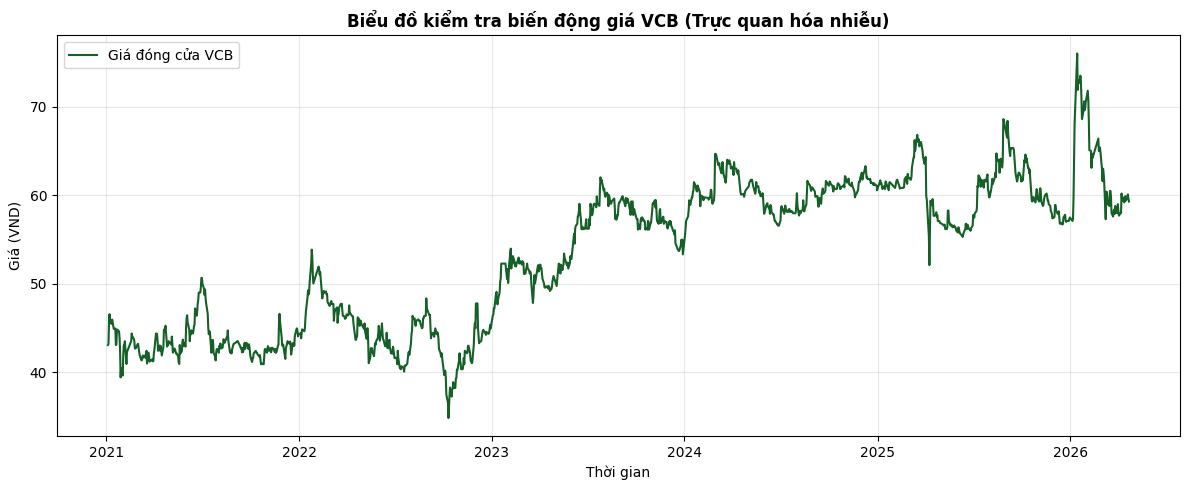

In [7]:
import sys
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Trỏ đường dẫn và kết nối Database
sys.path.append(os.path.abspath('./src'))
from data_loader import DB_PATH, get_connection

conn = get_connection()
df = pd.read_sql_query("SELECT * FROM Stock_Prices", conn)
conn.close()

df['Date'] = pd.to_datetime(df['Date'])

print("="*50)
print("BÁO CÁO KIỂM TRA CHẤT LƯỢNG DỮ LIỆU (NGUỒN: KBS)")
print("="*50)

# 2. Kiểm tra dữ liệu rỗng hoặc bằng 0
print("\n1️⃣ KIỂM TRA GIÁ TRỊ RỖNG / ZERO:")
zero_close = df[df['Close'] <= 0]
zero_volume = df[df['Volume'] == 0]
print(f" ➔ Số dòng có giá Close <= 0: {len(zero_close)} dòng", "✅" if len(zero_close) == 0 else "❌")
print(f" ➔ Số dòng có Volume = 0    : {len(zero_volume)} dòng (Thường là các ngày ngưng giao dịch)")

# 3. Kiểm tra logic OHLC (Open, High, Low, Close)
print("\n2️⃣ KIỂM TRA LOGIC NẾN NHẬT (OHLC):")
invalid_ohlc = df[(df['High'] < df['Low']) | (df['High'] < df['Close']) | (df['Low'] > df['Close'])]
print(f" ➔ Số dòng có giá High/Low phi logic: {len(invalid_ohlc)} dòng", "✅" if len(invalid_ohlc) == 0 else "❌")
if len(invalid_ohlc) > 0:
    display(invalid_ohlc.head())

# 4. Kiểm tra độ đồng đều của 30 mã
print("\n3️⃣ KIỂM TRA SỰ ĐỒNG ĐỀU GIỮA CÁC MÃ TÀI SẢN:")
summary = df.groupby('Ticker').agg(
    Total_Rows=('Date', 'count'),
    Min_Date=('Date', 'min'),
    Max_Date=('Date', 'max')
)
median_rows = summary['Total_Rows'].median()
summary['Hụt_so_với_trung_bình'] = median_rows - summary['Total_Rows']

# Lọc ra các mã bị hụt quá 5% số dòng so với trung bình chung
missing_data_tickers = summary[summary['Hụt_so_với_trung_bình'] > (median_rows * 0.05)]
if len(missing_data_tickers) > 0:
    print(" ⚠️ CẢNH BÁO: Các mã sau có lượng dữ liệu hụt bất thường so với mặt bằng chung:")
    display(missing_data_tickers)
else:
    print(" ➔ Tất cả 30 mã đều có số lượng dữ liệu đồng đều. ✅")

# 5. Kiểm tra Outlier (Lỗi nhân dữ liệu hoặc chưa điều chỉnh giá)
print("\n4️⃣ KIỂM TRA OUTLIER (Biến động > 8%/ngày):")
# Tính % thay đổi giá hàng ngày cho từng mã
df = df.sort_values(['Ticker', 'Date'])
df['Daily_Return'] = df.groupby('Ticker')['Close'].pct_change()

# Sàn HOSE biên độ 7%, nếu có ngày nào vọt > 8% (0.08) thì dữ liệu có vấn đề (vd: lỗi cổ tức)
outliers = df[(df['Daily_Return'] > 0.08) | (df['Daily_Return'] < -0.08)]
if len(outliers) > 0:
    print(f" ❌ CẢNH BÁO: Phát hiện {len(outliers)} điểm dữ liệu nghi ngờ sai lệch biên độ giá HOSE.")
    display(outliers[['Ticker', 'Date', 'Close', 'Daily_Return']].head(10))
else:
    print(" ➔ Không phát hiện biến động giá vượt trần/sàn bất hợp lý. Dữ liệu mượt mà. ✅")

# 6. Trực quan hóa kiểm tra mã đại diện 
ticker_test = 'VCB'
df_plot = df[df['Ticker'] == ticker_test]

plt.figure(figsize=(12, 5))
plt.plot(df_plot['Date'], df_plot['Close'], label=f'Giá đóng cửa {ticker_test}', color='#146026', linewidth=1.5)
plt.title(f'Biểu đồ kiểm tra biến động giá {ticker_test} (Trực quan hóa nhiễu)', fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Giá (VND)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
# Test lại Cov Matrix và MVP trên data 29 mã mới
import sys
import numpy as np
import pandas as pd
sys.path.append('../src')
from features import build_returns_matrix
from data_loader import VN30_TICKERS

# Build returns matrix 29 mã
matrix = build_returns_matrix(VN30_TICKERS, '2021-01-01', '2026-04-22')

# Tính Covariance Matrix — annualized
cov_matrix = matrix.cov() * 252

print("Shape:", cov_matrix.shape)
print("\nDiagonal (Variance của từng mã = Volatility²):")
for ticker in ['VCB', 'HPG', 'GAS', 'VIC']:
    var = cov_matrix.loc[ticker, ticker]
    vol = np.sqrt(var)
    print(f"  {ticker}: Var={var:.4f}, Volatility=√{var:.4f}={vol:.2%}")

print("\nSample — 5×5 góc trên trái:")
print(cov_matrix.iloc[:5, :5].round(4))

Shape: (29, 29)

Diagonal (Variance của từng mã = Volatility²):
  VCB: Var=0.0624, Volatility=√0.0624=24.98%
  HPG: Var=0.1144, Volatility=√0.1144=33.82%
  GAS: Var=0.1077, Volatility=√0.1077=32.82%
  VIC: Var=0.1383, Volatility=√0.1383=37.19%

Sample — 5×5 góc trên trái:
        ACB     BID     CTG     DGC     FPT
ACB  0.0723  0.0507  0.0567  0.0391  0.0366
BID  0.0507  0.1030  0.0716  0.0421  0.0390
CTG  0.0567  0.0716  0.1034  0.0512  0.0419
DGC  0.0391  0.0421  0.0512  0.1836  0.0500
FPT  0.0366  0.0390  0.0419  0.0500  0.0782


Correlation range:
  Min: 0.103
  Max: 0.767
  Mean: 0.375


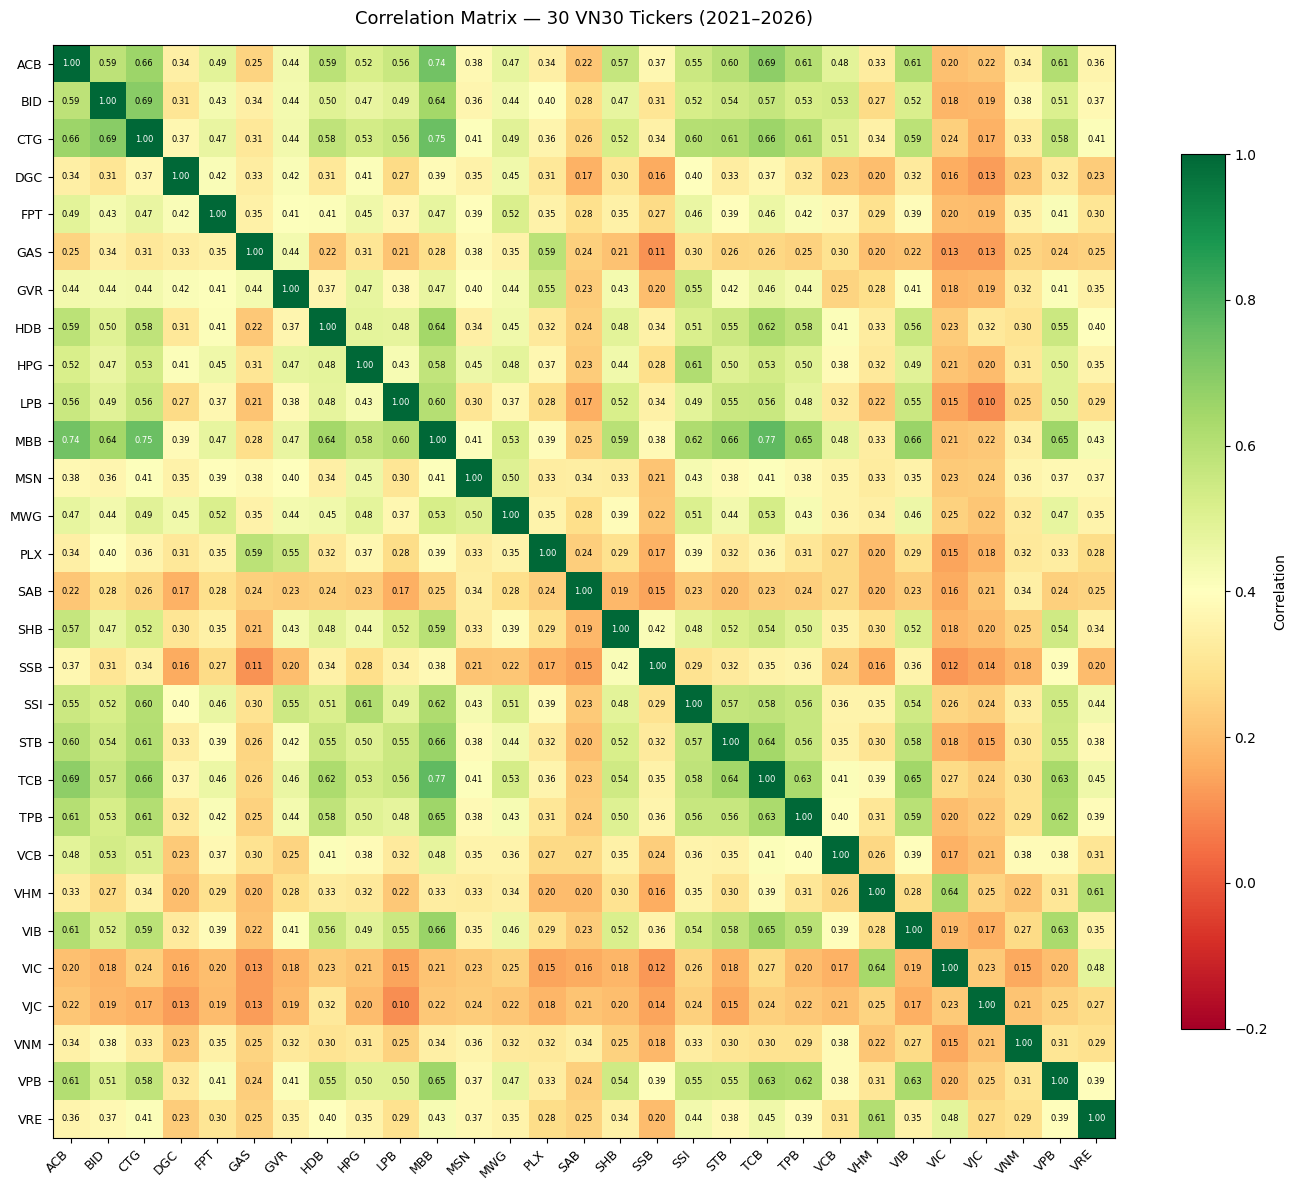

✅ Saved


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Correlation Matrix
corr_matrix = matrix.corr()

print("Correlation range:")
print(f"  Min: {corr_matrix.values[corr_matrix.values < 1].min():.3f}")
print(f"  Max: {corr_matrix.values[corr_matrix.values < 1].max():.3f}")
print(f"  Mean: {corr_matrix.values[corr_matrix.values < 1].mean():.3f}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(corr_matrix.values, cmap='RdYlGn',
               vmin=-0.2, vmax=1.0, aspect='auto')

# Ticks
ax.set_xticks(range(len(VN30_TICKERS)))
ax.set_yticks(range(len(VN30_TICKERS)))
ax.set_xticklabels(VN30_TICKERS, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(VN30_TICKERS, fontsize=9)

# Giá trị trong ô
for i in range(len(VN30_TICKERS)):
    for j in range(len(VN30_TICKERS)):
        val = corr_matrix.values[i, j]
        color = 'white' if val > 0.7 or val < 0.1 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Correlation')
ax.set_title('Correlation Matrix — 30 VN30 Tickers (2021–2026)',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

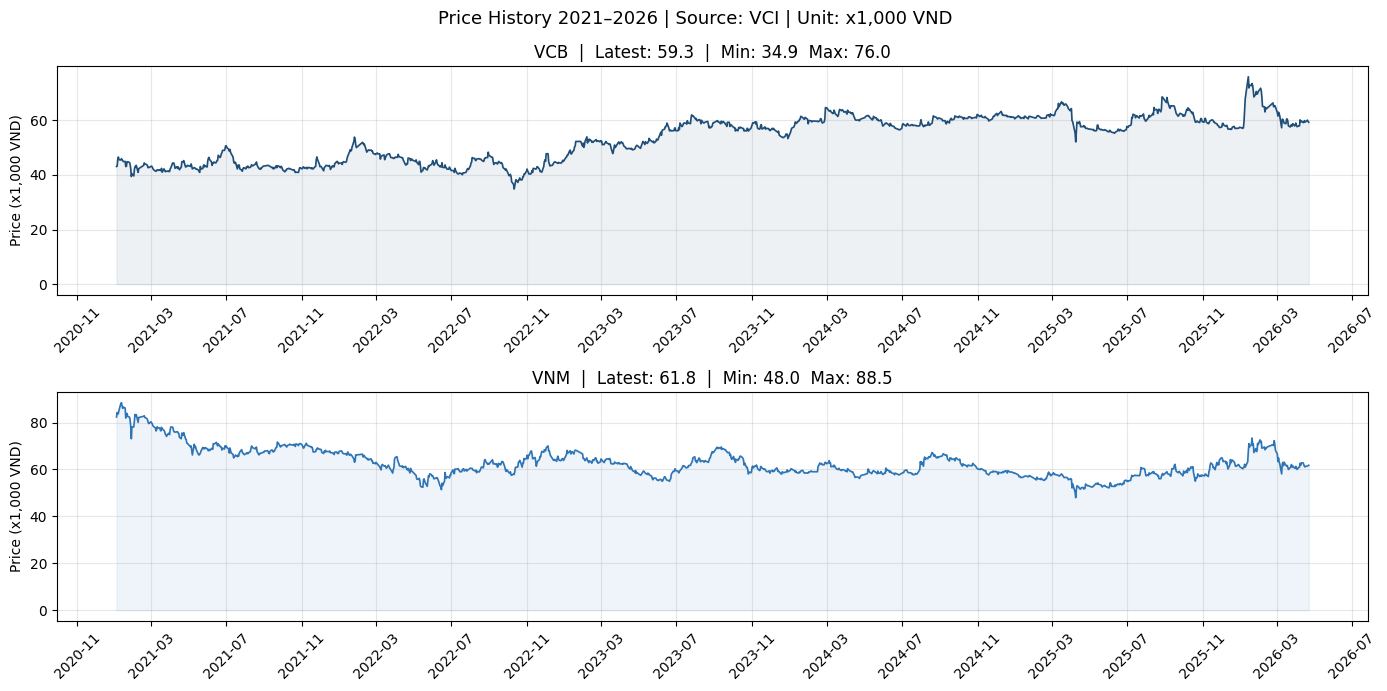

✅ Saved to reports/vcb_vnm_price_history2.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from data_loader import load_from_db

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('Price History 2021–2026 | Source: VCI | Unit: x1,000 VND', fontsize=13)

for ax, ticker, color in zip(axes, ['VCB', 'VNM'], ['#1F4E79', '#2E75B6']):
    df = load_from_db(ticker, '2021-01-01', '2026-04-22')
    ax.plot(df.index, df['Close'], color=color, linewidth=1.2)
    ax.fill_between(df.index, df['Close'], alpha=0.08, color=color)
    ax.set_title(f'{ticker}  |  Latest: {df["Close"].iloc[-1]:.1f}  |  '
                 f'Min: {df["Close"].min():.1f}  Max: {df["Close"].max():.1f}')
    ax.set_ylabel('Price (x1,000 VND)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/vcb_vnm_price_history2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/vcb_vnm_price_history2.png")

=== MISSING DATES VCB ===
Ngày làm việc (B)  : 1384
Ngày trong DB      : 1320
Ngày thiếu (lễ/tết): 64

10 ngày thiếu đầu tiên:
  2021-01-01 Fri
  2021-02-10 Wed
  2021-02-11 Thu
  2021-02-12 Fri
  2021-02-15 Mon
  2021-02-16 Tue
  2021-04-21 Wed
  2021-04-30 Fri
  2021-05-03 Mon
  2021-09-02 Thu

=== ADJUSTED CLOSE CHECK ===
Ngày biến động >10% qua đêm: 0


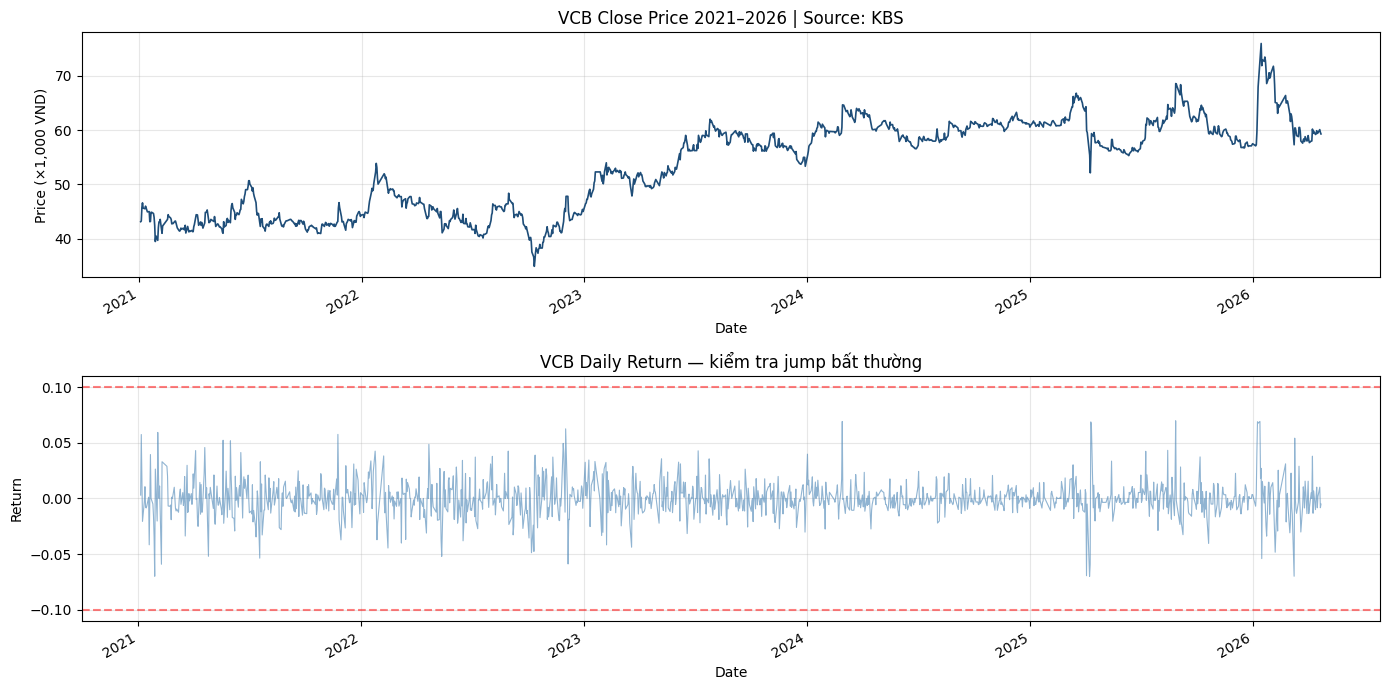

✅ Chart saved


In [8]:
import matplotlib.pyplot as plt
from data_loader import load_from_db

# ── Bước 4: missing dates ──────────────────────────────────────
full_range = pd.date_range(start='2021-01-01', end='2026-04-22', freq='B')
df_vcb = load_from_db('VCB', '2021-01-01', '2026-04-22')
missing_dates = full_range.difference(df_vcb.index)

print("=== MISSING DATES VCB ===")
print(f"Ngày làm việc (B)  : {len(full_range)}")
print(f"Ngày trong DB      : {len(df_vcb)}")
print(f"Ngày thiếu (lễ/tết): {len(missing_dates)}")
print(f"\n10 ngày thiếu đầu tiên:")
for d in missing_dates[:10]:
    print(f"  {d.strftime('%Y-%m-%d %a')}")

# ── Bước 7: kiểm tra Adjusted Close ───────────────────────────
overnight = df_vcb['Close'].pct_change()
big_moves = overnight[overnight.abs() > 0.1]

print(f"\n=== ADJUSTED CLOSE CHECK ===")
print(f"Ngày biến động >10% qua đêm: {len(big_moves)}")
if len(big_moves) > 0:
    print(big_moves.to_string())

# ── Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

df_vcb['Close'].plot(ax=axes[0], color='#1F4E79', linewidth=1.2)
axes[0].set_title('VCB Close Price 2021–2026 | Source: KBS')
axes[0].set_ylabel('Price (×1,000 VND)')
axes[0].grid(True, alpha=0.3)

overnight.plot(ax=axes[1], color='steelblue', alpha=0.6, linewidth=0.8)
axes[1].axhline(y=0.1,  color='red', linestyle='--', alpha=0.5)
axes[1].axhline(y=-0.1, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('VCB Daily Return — kiểm tra jump bất thường')
axes[1].set_ylabel('Return')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/vcb_data_quality_check2.png', dpi=150)
plt.show()
print("✅ Chart saved")

In [13]:
import importlib
import portfolio_metrics
importlib.reload(portfolio_metrics)
from portfolio_metrics import (expected_returns, covariance_matrix,
                                portfolio_stats, display_metrics)
import numpy as np

START = '2021-01-01'
END   = '2026-04-22'

# ── Test 3 mã verify tay ──────────────────────────────────────
test_tickers = ['VCB', 'VNM', 'HPG']
mu3  = expected_returns(test_tickers, START, END)
cov3 = covariance_matrix(test_tickers, START, END)
w3   = np.array([1/3, 1/3, 1/3])

stats = portfolio_stats(w3, mu3, cov3)

print("=== Python output (VCB + VNM + HPG, equal weights) ===")
print(f"Return    : {stats['port_return']:.6f}  ({stats['port_return']:.2%})")
print(f"Volatility: {stats['port_volatility']:.6f}  ({stats['port_volatility']:.2%})")
print(f"Sharpe    : {stats['sharpe_ratio']:.6f}")
print(f"Variance  : {stats['port_variance']:.6f}")

# ── Tính tay verify ───────────────────────────────────────────
print("\n=== Tính tay verify ===")
r_manual = (mu3['VCB'] + mu3['VNM'] + mu3['HPG']) / 3
print(f"Return tay : {r_manual:.6f}  {'✅' if abs(r_manual - stats['port_return']) < 1e-8 else '❌'}")

var_manual = float(w3 @ cov3.values @ w3)
vol_manual = np.sqrt(var_manual)
print(f"Vol tay    : {vol_manual:.6f}  {'✅' if abs(vol_manual - stats['port_volatility']) < 1e-8 else '❌'}")

sharpe_manual = (r_manual - 0.045) / vol_manual
print(f"Sharpe tay : {sharpe_manual:.6f}  {'✅' if abs(sharpe_manual - stats['sharpe_ratio']) < 1e-8 else '❌'}")

# ── Equal weights 30 mã ───────────────────────────────────────
from data_loader import VN30_TICKERS
N  = len(VN30_TICKERS)
mu = expected_returns(VN30_TICKERS, START, END)
cov = covariance_matrix(VN30_TICKERS, START, END)

w_equal = np.array([1/N] * N)
display_metrics(VN30_TICKERS, w_equal, mu, cov,
                label='Equal Weights — 30 VN30 tickers')

=== Python output (VCB + VNM + HPG, equal weights) ===
Return    : 0.070903  (7.09%)
Volatility: 0.215554  (21.56%)
Sharpe    : 0.120170
Variance  : 0.046463

=== Tính tay verify ===
Return tay : 0.070903  ✅
Vol tay    : 0.215554  ✅
Sharpe tay : 0.120170  ✅

  Equal Weights — 30 VN30 tickers
  Expected Return    :   33.84%
  Volatility (Risk)  :   20.90%
  Sharpe Ratio       :    1.404
Ticker Weight Exp Return
   ACB   3.3%      18.3%
   BID   3.3%      19.2%
   CTG   3.3%      31.4%
   DGC   3.3%     -40.0%
   FPT   3.3%     -28.6%
   GAS   3.3%      40.5%
   GVR   3.3%      25.0%
   HDB   3.3%      54.4%
   HPG   3.3%      32.8%
   LPB   3.3%      44.8%
   MBB   3.3%      42.0%
   MSN   3.3%      29.4%
   MWG   3.3%      38.5%
   PLX   3.3%      22.6%
   SAB   3.3%       4.7%
   SHB   3.3%      39.2%
   SSB   3.3%      -8.0%
   SSI   3.3%      39.7%
   STB   3.3%      63.8%
   TCB   3.3%      21.0%
   TPB   3.3%      30.0%
   VCB   3.3%       9.2%
   VHM   3.3%     103.2%
   VIB   3.

,Ticker,Weight,Exp Return
0,ACB,3.3%,18.3%
1,BID,3.3%,19.2%
2,CTG,3.3%,31.4%
3,DGC,3.3%,-40.0%
4,FPT,3.3%,-28.6%
5,GAS,3.3%,40.5%
6,GVR,3.3%,25.0%
7,HDB,3.3%,54.4%
8,HPG,3.3%,32.8%
9,LPB,3.3%,44.8%


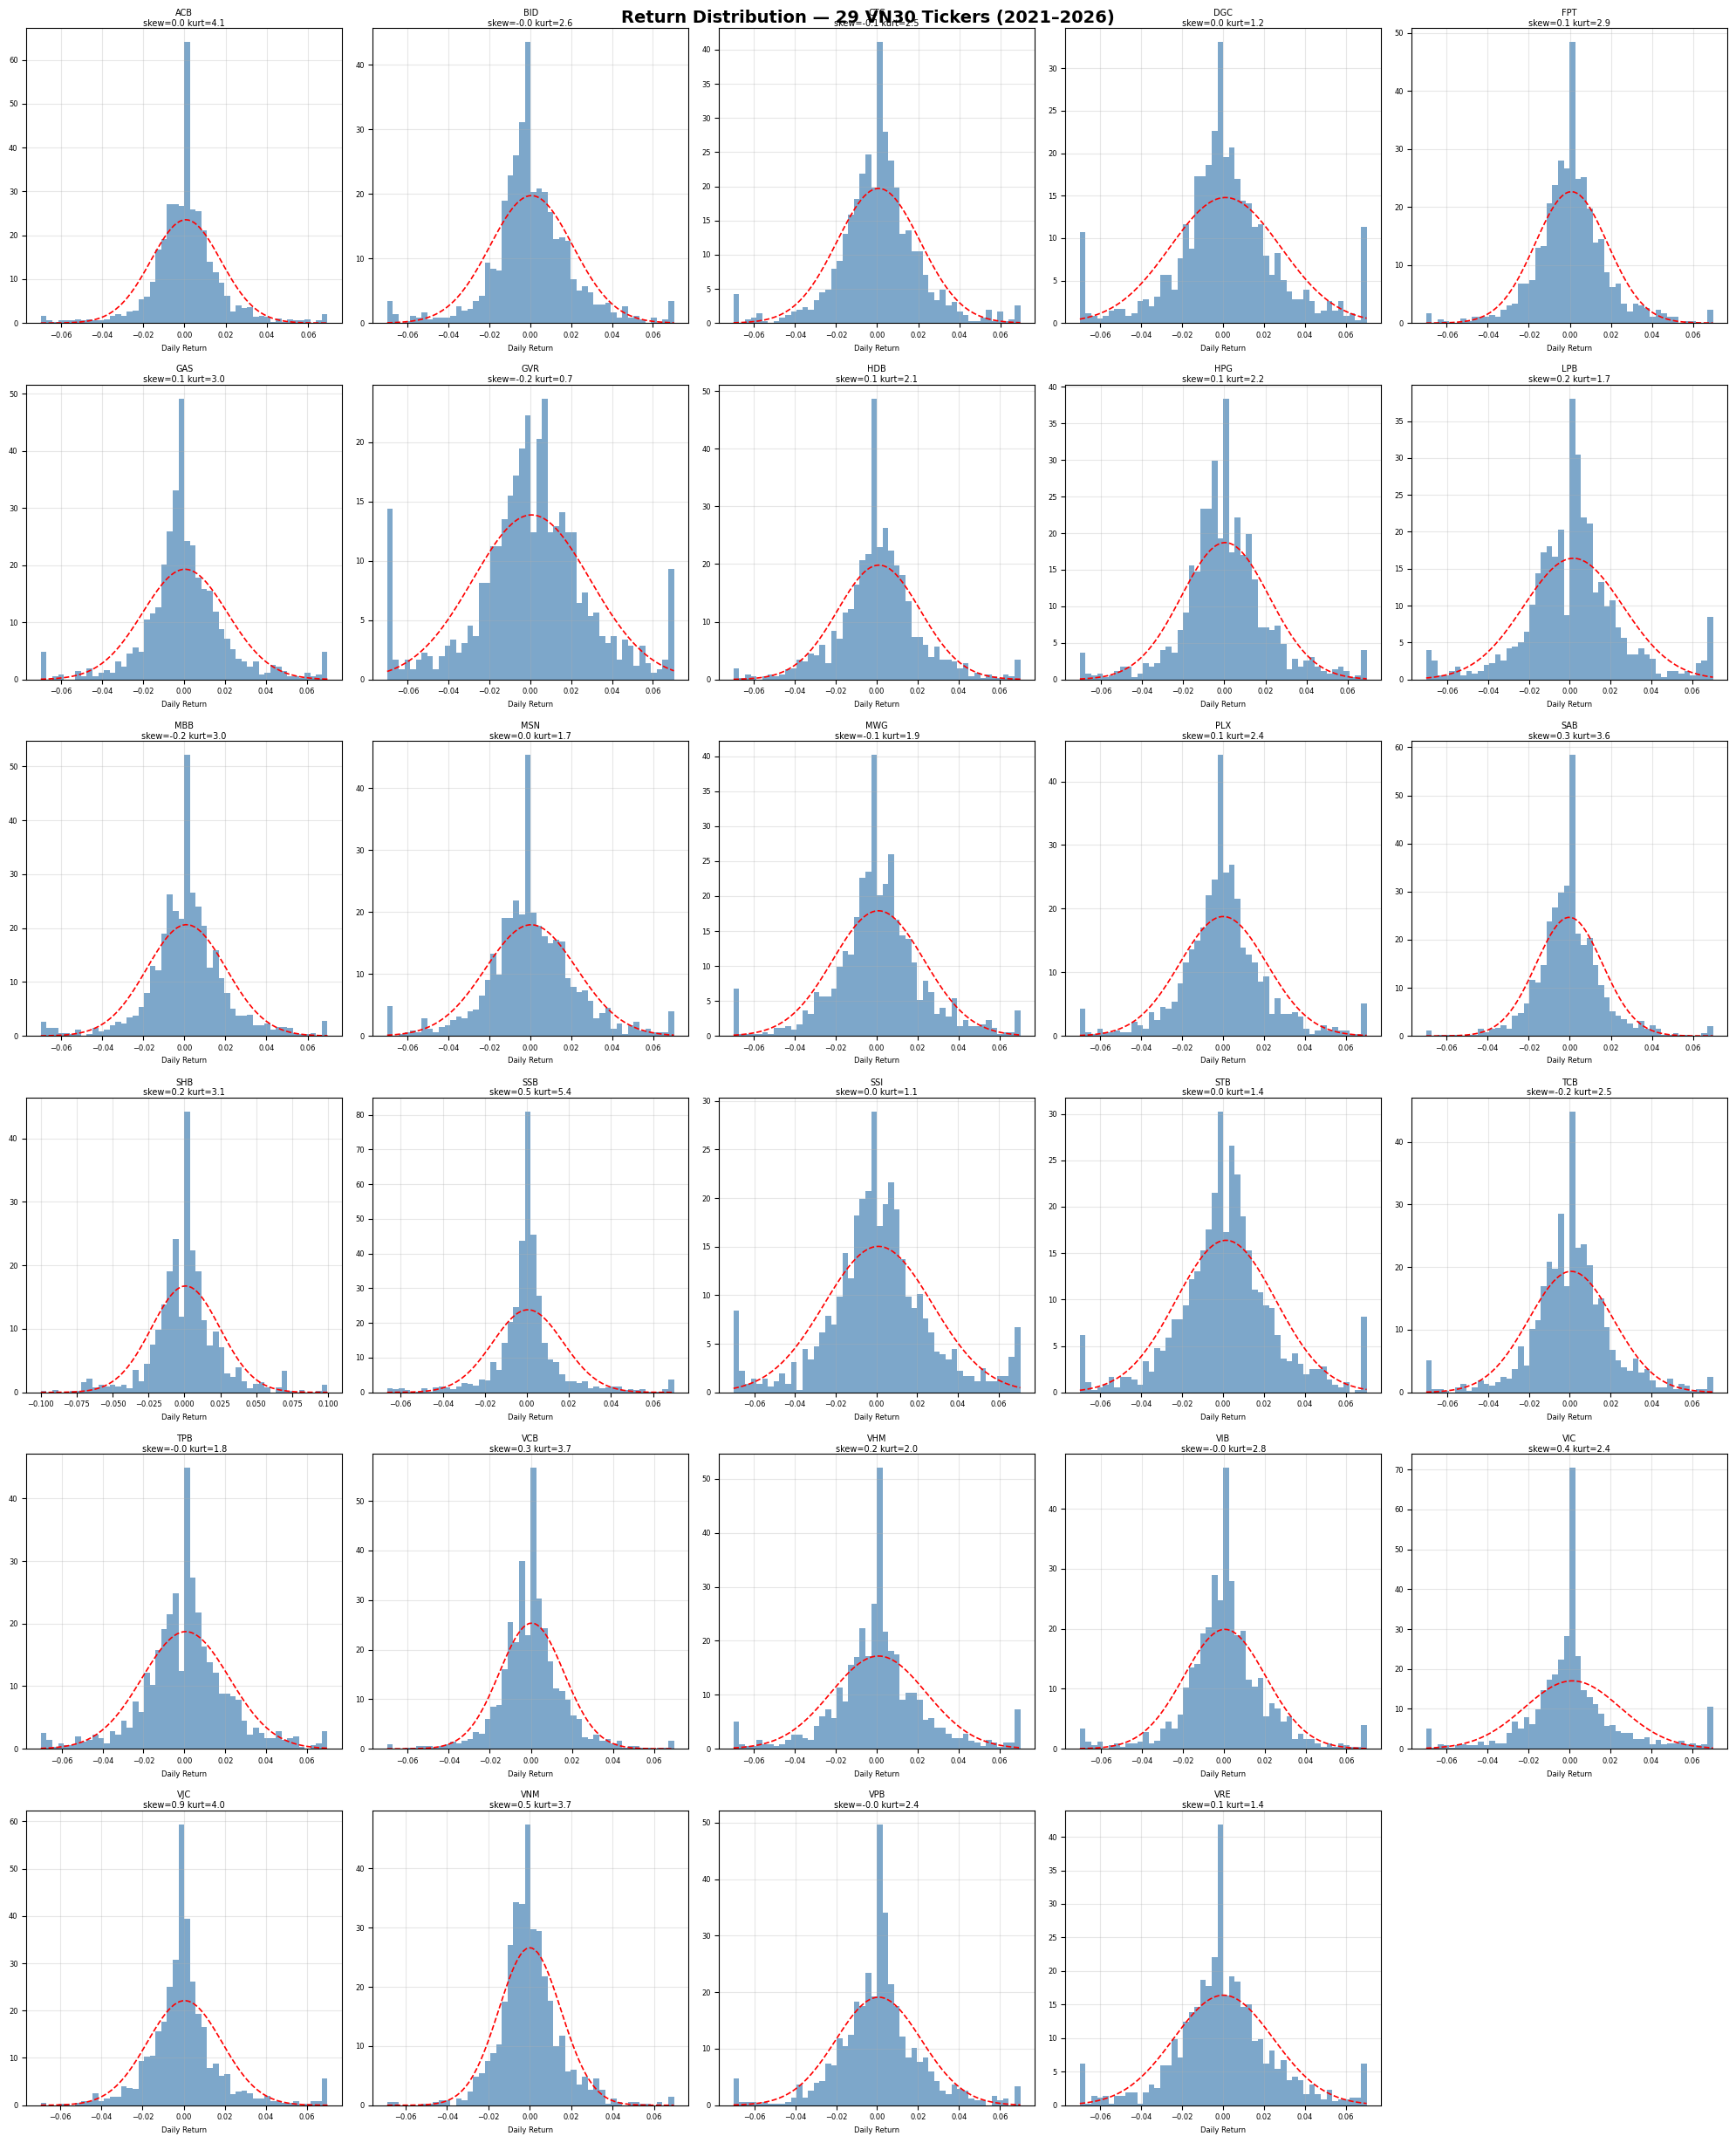

✅ Saved to reports/return_distributions_30tickers2.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
sys.path.append('../src')
from features import build_returns_matrix
from data_loader import VN30_TICKERS
import numpy as np
from scipy import stats

# Build returns matrix 30 mã
matrix = build_returns_matrix(VN30_TICKERS, '2021-01-01', '2026-04-22')

# Plot 30 histograms
fig = plt.figure(figsize=(20, 25))
fig.suptitle('Return Distribution — 29 VN30 Tickers (2021–2026)',
             fontsize=14, fontweight='bold', y=0.98)

for i, ticker in enumerate(VN30_TICKERS):
    ax = fig.add_subplot(6, 5, i + 1)
    ret = matrix[ticker].dropna()

    # Histogram
    ax.hist(ret, bins=50, color='steelblue', alpha=0.7, density=True)

    # Normal distribution overlay
    mu, sigma = ret.mean(), ret.std()
    x = np.linspace(ret.min(), ret.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color='red', linewidth=1.2, linestyle='--')

    # Skewness và kurtosis
    skew = ret.skew()
    kurt = ret.kurtosis()

    ax.set_title(f'{ticker}\nskew={skew:.1f} kurt={kurt:.1f}',
                 fontsize=7, pad=2)
    ax.set_xlabel('Daily Return', fontsize=6)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/return_distributions_30tickers2.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to reports/return_distributions_30tickers2.png")